In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("saurabhshahane/twitter-sentiment-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'twitter-sentiment-dataset' dataset.
Path to dataset files: /kaggle/input/twitter-sentiment-dataset


In [2]:
!ls /kaggle/input/twitter-sentiment-dataset

Twitter_Data.csv


In [3]:
PATH_CSV = path + '/Twitter_Data.csv'

# 1 - instalamos librerias

In [4]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 2 - cargamos dataset

In [5]:
df = pd.read_csv(PATH_CSV)
df

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0
...,...,...
162975,why these 456 crores paid neerav modi not reco...,-1.0
162976,dear rss terrorist payal gawar what about modi...,-1.0
162977,did you cover her interaction forum where she ...,0.0
162978,there big project came into india modi dream p...,0.0


# EDA

In [6]:
df.dtypes

,0
clean_text,object
category,float64


In [7]:
df.isnull().sum()

,0
clean_text,4
category,7


In [8]:
df.dropna(inplace=True)

# LIMPIEZA DE TEXTO SIMPLE

In [9]:
def clean_text(s: str) -> str:
    s = str(s).lower()
    s = re.sub(r"http\S+|www\S+", " url ", s)
    s = re.sub(r"@\w+", " user ", s)
    s = re.sub(r"#", " ", s)
    s = re.sub(r"\d+", " num ", s)
    s = re.sub(r"[^a-z\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

In [10]:
df = df[['clean_text', 'category']].copy()
df = df.dropna()

In [11]:

# category puede venir como float, por eso lo convertimos
df['category'] = df['category'].astype(int)

df["text"] = df["clean_text"].astype(str).apply(clean_text)
df

,clean_text,category,text
0,when modi promised “minimum government maximum...,-1,when modi promised minimum government maximum ...
1,talk all the nonsense and continue all the dra...,0,talk all the nonsense and continue all the dra...
2,what did just say vote for modi welcome bjp t...,1,what did just say vote for modi welcome bjp to...
3,asking his supporters prefix chowkidar their n...,1,asking his supporters prefix chowkidar their n...
4,answer who among these the most powerful world...,1,answer who among these the most powerful world...
...,...,...,...
162975,why these 456 crores paid neerav modi not reco...,-1,why these num crores paid neerav modi not reco...
162976,dear rss terrorist payal gawar what about modi...,-1,dear rss terrorist payal gawar what about modi...
162977,did you cover her interaction forum where she ...,0,did you cover her interaction forum where she ...
162978,there big project came into india modi dream p...,0,there big project came into india modi dream p...


# hacemos label encoding

In [12]:
# Etiquetas originales del dataset:
# -1 = negative
#  0 = neutral
#  1 = positive

le = LabelEncoder()
y = le.fit_transform(df["category"])   # -1,0,1 -> 0,1,2
X_text = df["text"].tolist()

In [13]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print("Clases originales:", list(le.classes_))
print("Train:", len(X_train_text), "Test:", len(X_test_text))
print("Distribución train:", pd.Series(y_train).value_counts(normalize=True).sort_index().round(3).to_dict())
print("Distribución test:", pd.Series(y_test).value_counts(normalize=True).sort_index().round(3).to_dict())

Clases originales: [np.int64(-1), np.int64(0), np.int64(1)]
Train: 130375 Test: 32594
Distribución train: {0: 0.218, 1: 0.339, 2: 0.443}
Distribución test: {0: 0.218, 1: 0.339, 2: 0.443}


# ENTRENAMIENTO CON FASTTEXT

In [14]:
!pip -q install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 79.4 MB/s eta 0:00:00


In [15]:
from gensim.models import FastText

In [16]:
train_tokens = [text.split() for text in X_train_text]
test_tokens = [text.split() for text in X_test_text]

print(train_tokens[:3])

[['this', 'the', 'same', 'person', 'who', 'had', 'threatened', 'cut', 'modi', 'pieces', 'does', 'not', 'deserve', 'election', 'fray'], ['dismissed', 'indian', 'soldier', 'announces', 'contest', 'elections', 'against', 'modi'], ['modi', 'raaj', 'rojgaar', 'has', 'drowned', 'arabian', 'seaand', 'termed', 'flopped', 'last', 'years']]


In [17]:
fasttext_model = FastText(
    sentences=train_tokens,
    vector_size=100,
    window=4,
    min_count=1,
    workers=4,
    sg=1,
    epochs=10
)

print('FastText listo')
print('Tamaño del vocabulario:', len(fasttext_model.wv))
print('Dimensión del embedding:', fasttext_model.vector_size)

FastText listo
Tamaño del vocabulario: 87807
Dimensión del embedding: 100


## Probamos embeddings de palabras conocidas y desconocidas

Una ventaja de FastText es que puede construir vectores para palabras que no estuvieron exactamente en el vocabulario, gracias al uso de subpalabras.

In [18]:
palabra_conocida = 'good'
palabra_desconocida = 'goooood'

print('Vector palabra conocida:', fasttext_model.wv[palabra_conocida][:10])
print('Vector palabra desconocida:', fasttext_model.wv[palabra_desconocida][:10])
print('Shape:', fasttext_model.wv[palabra_desconocida].shape)

Vector palabra conocida: [-0.10125443  0.33024862  0.27123225  0.05305816 -0.14298703  0.30636576
 -0.12439705 -0.07756504 -0.1610234   0.36135638]
Vector palabra desconocida: [-0.47946396  0.29021403  0.04448463  0.2820375  -0.19259828  0.44789016
 -0.11766258  0.21416102  0.11150318  0.21753277]
Shape: (100,)


# Vectorizar cada tweet

In [19]:
def sent_vec_fasttext(tokens, model):
    if len(tokens) == 0:
        return np.zeros(model.vector_size)

    vecs = [model.wv[word] for word in tokens]

    if len(vecs) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vecs, axis=0)

X_train_vec = np.vstack([sent_vec_fasttext(tokens, fasttext_model) for tokens in train_tokens])
X_test_vec = np.vstack([sent_vec_fasttext(tokens, fasttext_model) for tokens in test_tokens])

X_train_vec.shape, X_test_vec.shape

((130375, 100), (32594, 100))

# ENTRENAMIENTO

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [23]:
clf_fasttext = LogisticRegression(max_iter=3000, multi_class='auto')
clf_fasttext.fit(X_train_vec, y_train)

y_pred = clf_fasttext.predict(X_test_vec)

print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.6000184082960054
              precision    recall  f1-score   support

          -1       0.49      0.27      0.35      7102
           0       0.63      0.62      0.62     11042
           1       0.61      0.75      0.67     14450

    accuracy                           0.60     32594
   macro avg       0.57      0.55      0.55     32594
weighted avg       0.59      0.60      0.58     32594



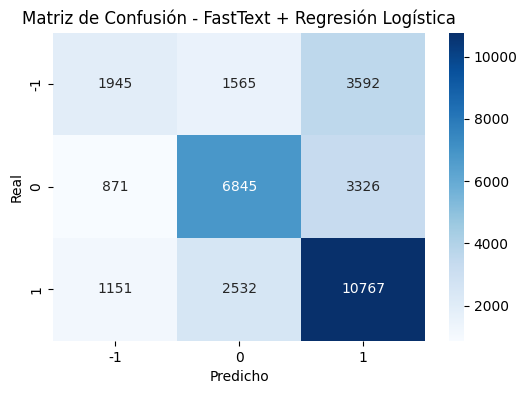

In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[str(c) for c in le.classes_],
    yticklabels=[str(c) for c in le.classes_]
)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión - FastText + Regresión Logística')
plt.show()

# PROBAMOS PREDICCIONES

In [25]:
def predict_sentiment_fasttext(msg: str):
    msg_clean = clean_text(msg)
    tokens = msg_clean.split()
    vector = sent_vec_fasttext(tokens, fasttext_model).reshape(1, -1)

    pred_idx = clf_fasttext.predict(vector)[0]
    pred_label = le.inverse_transform([pred_idx])[0]

    probs = clf_fasttext.predict_proba(vector)[0]
    prob_dict = {
        str(label): round(float(prob), 4)
        for label, prob in zip(le.classes_, probs)
    }

    return {
        'texto_limpio': msg_clean,
        'prediccion': int(pred_label),
        'probabilidades': prob_dict
    }

In [26]:
print(predict_sentiment_fasttext('I love this phone, it is amazing'))
print(predict_sentiment_fasttext('This service is terrible and very bad'))
print(predict_sentiment_fasttext('The product is okay, nothing special'))

{'texto_limpio': 'i love this phone it is amazing', 'prediccion': 1, 'probabilidades': {'-1': 0.0684, '0': 0.1344, '1': 0.7972}}
{'texto_limpio': 'this service is terrible and very bad', 'prediccion': 1, 'probabilidades': {'-1': 0.1917, '0': 0.003, '1': 0.8053}}
{'texto_limpio': 'the product is okay nothing special', 'prediccion': 1, 'probabilidades': {'-1': 0.1195, '0': 0.4368, '1': 0.4438}}
